## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
from keras.datasets import fashion_mnist
(X_train, Y_train), (X_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


4423680/4422102 [==============================] - 1s 0us/step


### Find no.of samples are there in training and test datasets

In [0]:
X_train.shape

(60000, 28, 28)

In [0]:
X_test.shape

(10000, 28, 28)

### Find dimensions of an image in the dataset

In [0]:
X_train[0].shape

(28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
import tensorflow as tf

y_train = tf.keras.utils.to_categorical(Y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
norm_img_train = X_train/(255.0)

In [0]:
norm_img_test = X_test /(255.0)

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
x_train = norm_img_train.reshape(60000,28,28,1)
x_test = norm_img_test.reshape(10000,28,28,1)

### Import the necessary layers from keras to build the model

In [0]:
tf.keras.backend.clear_session()
#Initialize model, reshape & normalize data
model = tf.keras.models.Sequential()

#Reshape data from 2D (28,28) to 3D (28, 28, 1)
#model.add(tf.keras.layers.Reshape((28,28,1),input_shape=(28,28)))

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
#Add first convolutional layer
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                 kernel_size=(3,3), #Size of the filter
                                 activation='relu'))
#Add 2ND convolutional layer
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                 kernel_size=(3,3), #Size of the filter
                                 activation='relu'))

#Add MaxPooling layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

#Add another dropout layer
model.add(tf.keras.layers.Dropout(0.25))

#Add flatten layer
model.add(tf.keras.layers.Flatten())

#Add second convolutional layer
model.add(tf.keras.layers.Dense(128, 
                                activation='relu'))


model.add(tf.keras.layers.Dense(10, activation='softmax'))

#model.add(tf.keras.layers.GlobalAveragePooling2D())



### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
tf.keras.callbacks.Callback()
reduce_lr = tf.keras.callbacks.EarlyStopping(monitor='acc', min_delta=0, patience=5 )
model.fit(x_train, y_train,
                          epochs=10,callbacks=[reduce_lr])





Epoch 1/10
60000/60000 [==============================] - 8s 136us/sample - loss: 0.3981 - acc: 0.8567
Epoch 2/10
60000/60000 [==============================] - 6s 104us/sample - loss: 0.2579 - acc: 0.9056
Epoch 3/10
60000/60000 [==============================] - 6s 105us/sample - loss: 0.2117 - acc: 0.9221
Epoch 4/10
60000/60000 [==============================] - 6s 104us/sample - loss: 0.1786 - acc: 0.9328
Epoch 5/10
60000/60000 [==============================] - 6s 104us/sample - loss: 0.1498 - acc: 0.9441
Epoch 6/10
60000/60000 [==============================] - 6s 104us/sample - loss: 0.1276 - acc: 0.9521
Epoch 7/10
60000/60000 [==============================] - 6s 106us/sample - loss: 0.1086 - acc: 0.9583
Epoch 8/10
60000/60000 [==============================] - 6s 107us/sample - loss: 0.0931 - acc: 0.9652
Epoch 9/10
60000/60000 [==============================] - 6s 105us/sample - loss: 0.0779 - acc: 0.9704
Epoch 10/10
60000/60000 [==============================] - 6s 104us/sampl

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
import tensorflow as tf


In [0]:
datagen =tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,
                                                                   width_shift_range=0.2,
                                                                   height_shift_range=0.2,
                                                                   horizontal_flip=True)

In [0]:
datagen.fit(x_train)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

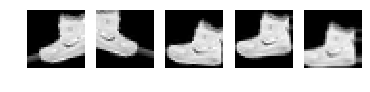

In [0]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1],batch_size =1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(),cmap='gray')
    plt.plot()
plt.show()


### Run the above model using fit_generator()

In [0]:
model.fit_generator(datagen.flow(x_train,y_train,batch_size=32),validation_data=(x_test,y_test),epochs=10)

Epoch 1/10
1875/1875 [==============================] - 18s 9ms/step - loss: 0.7516 - acc: 0.7238 - val_loss: 0.3858 - val_acc: 0.8579
Epoch 2/10
1875/1875 [==============================] - 18s 10ms/step - loss: 0.5621 - acc: 0.7896 - val_loss: 0.3681 - val_acc: 0.8687
Epoch 3/10
1875/1875 [==============================] - 18s 9ms/step - loss: 0.5108 - acc: 0.8099 - val_loss: 0.3600 - val_acc: 0.8697
Epoch 4/10
1875/1875 [==============================] - 18s 9ms/step - loss: 0.4823 - acc: 0.8216 - val_loss: 0.3463 - val_acc: 0.8728
Epoch 5/10
1875/1875 [==============================] - 18s 10ms/step - loss: 0.4619 - acc: 0.8290 - val_loss: 0.3237 - val_acc: 0.8833
Epoch 6/10
1875/1875 [==============================] - 18s 10ms/step - loss: 0.4466 - acc: 0.8344 - val_loss: 0.3258 - val_acc: 0.8813
Epoch 7/10
1875/1875 [==============================] - 18s 9ms/step - loss: 0.4355 - acc: 0.8382 - val_loss: 0.3182 - val_acc: 0.8854
Epoch 8/10
1875/1875 [==============================

###  Report the final train and validation accuracy

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
import tensorflow as tf
tf.reset_default_graph()
tf.set_random_seed(42)

### **Load CIFAR10 dataset**

In [0]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170500096/170498071 [==============================] - 13s 0us/step


In [0]:
x_train.shape

(50000, 32, 32, 3)

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
transform_fn = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True,
                                                              width_shift_range=0.2,
                                                              height_shift_range=0.2,
                                                              rotation_range=30,
                                                              shear_range=0.2)

### **Prepare/fit the generator.**

In [0]:
transform_fn.fit(x_train)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

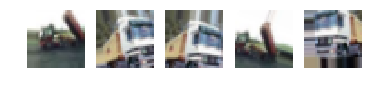

In [0]:
#flower_image = tf.keras.preprocessing.image.load_img(image_file)
#flower_array = tf.keras.preprocessing.image.img_to_array(flower_image)

#Inspect image
#flower_image
import numpy as np
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[1:3],batch_size =1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().astype(np.uint8).squeeze())
    plt.plot()
plt.show()